In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
!pip install -U scikit-learn==1.7.2

In [4]:
data=pd.read_csv("Bank Customer Churn Prediction.csv")

In [5]:
data.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


In [7]:
data.describe()

,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [8]:
data.max()

,0
customer_id,15815690
credit_score,850
country,Spain
gender,Male
age,92
tenure,10
balance,250898.09
products_number,4
credit_card,1
active_member,1


In [9]:
features=data.drop(['churn','customer_id'],axis=1)
target=data['churn']
features


,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10
...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77
9997,709,France,Female,36,7,0.00,1,0,1,42085.58
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52


In [10]:
cat_attributes = ['country', 'gender']

num_attributes = features.drop(cat_attributes, axis=1).columns.tolist()
num_attributes

['credit_score',
 'age',
 'tenure',
 'balance',
 'products_number',
 'credit_card',
 'active_member',
 'estimated_salary']

In [11]:
corr_matrix = data[num_attributes].corr()

corr_matrix

,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary
credit_score,1.000000,-0.003965,0.000842,0.006268,0.012238,-0.005458,0.025651,-0.001384
age,-0.003965,1.000000,-0.009997,0.028308,-0.030680,-0.011721,0.085472,-0.007201
tenure,0.000842,-0.009997,1.000000,-0.012254,0.013444,0.022583,-0.028362,0.007784
balance,0.006268,0.028308,-0.012254,1.000000,-0.304180,-0.014858,-0.010084,0.012797
products_number,0.012238,-0.030680,0.013444,-0.304180,1.000000,0.003183,0.009612,0.014204
credit_card,-0.005458,-0.011721,0.022583,-0.014858,0.003183,1.000000,-0.011866,-0.009933
active_member,0.025651,0.085472,-0.028362,-0.010084,0.009612,-0.011866,1.000000,-0.011421
estimated_salary,-0.001384,-0.007201,0.007784,0.012797,0.014204,-0.009933,-0.011421,1.000000


<Axes: >

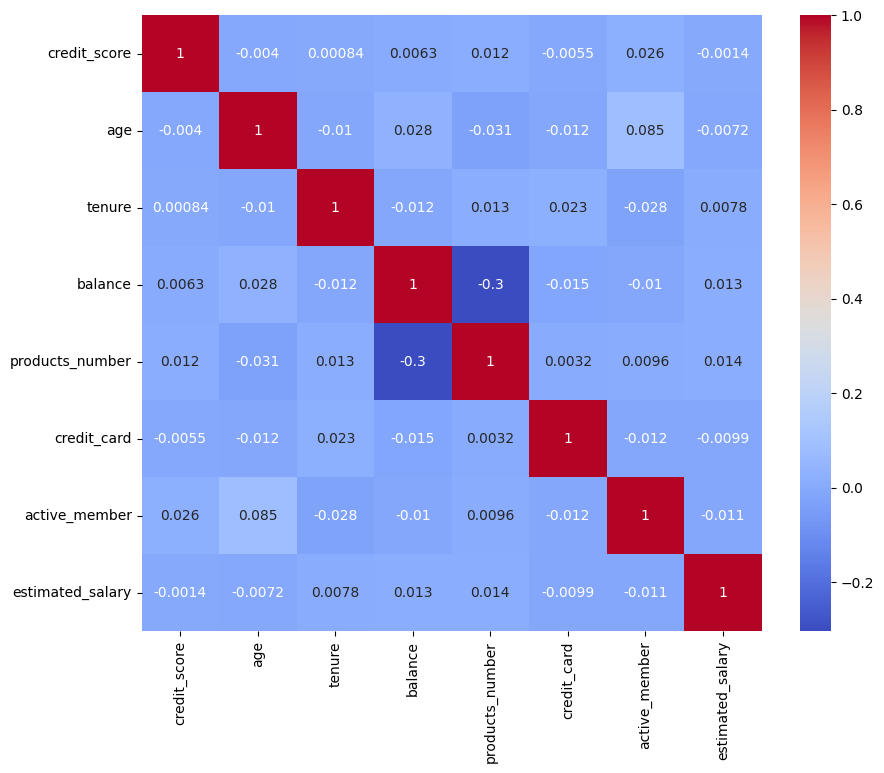

In [12]:
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix,
            annot=True,
            cmap="coolwarm")

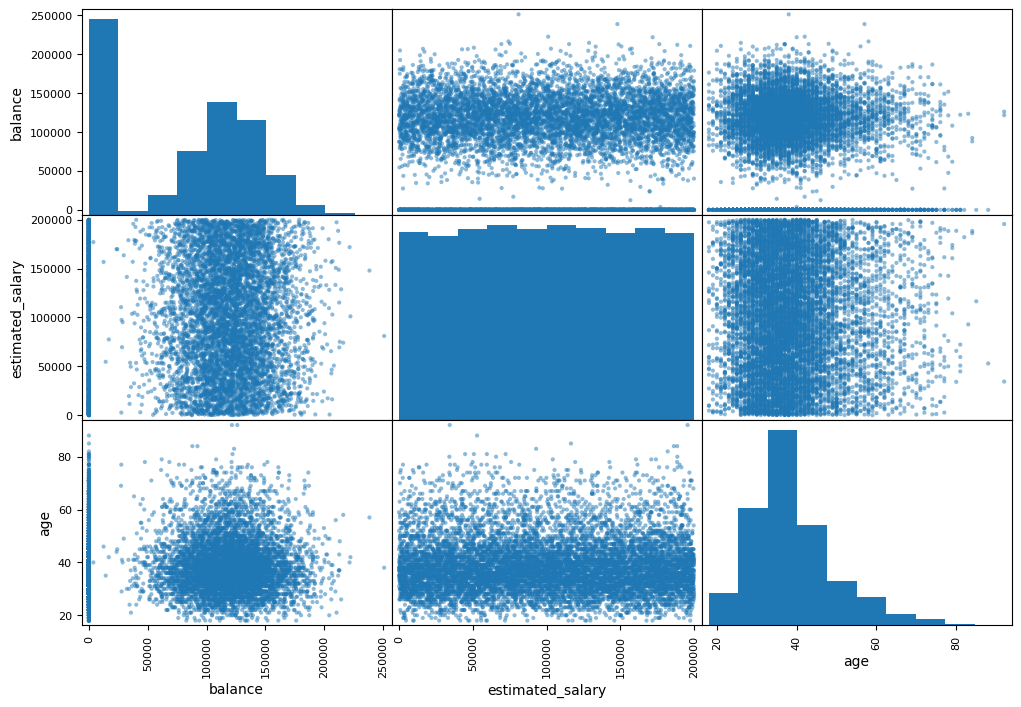

In [13]:
from pandas.plotting import scatter_matrix
attributes = ['balance','estimated_salary','age']
scatter_matrix(data[attributes], figsize=(12, 8))
plt.show()

<Axes: xlabel='balance', ylabel='age'>

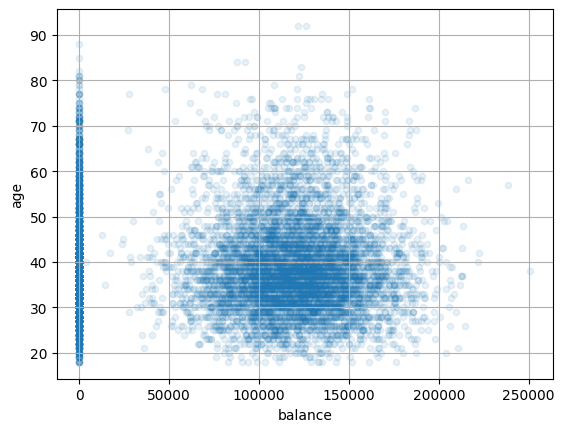

In [14]:
data.plot(kind="scatter", x="balance", y="age", alpha=0.1,
grid=True)

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

def categorical_analysis(data, feature, target='churn'):
    # 1. Bar Plot
    plt.figure(figsize=(6,4))
    sns.barplot(x=feature, y=target, data=data)
    plt.title(f'{feature} vs {target}')
    plt.show()

    # 2. Crosstab
    table = pd.crosstab(data[feature], data[target])
    print("\nCrosstab:\n")
    print(table)

    # 3. Chi-Square Test
    chi2, p, dof, expected = chi2_contingency(table)
    print("\nChi-Square Test")
    print("P-value:", p)

    # 4. Interpretation & Feature Selection Rule
    if p < 0.05:
        print("Result: Significant relationship exists. Keep this feature.")
        return True  # Keep
    else:
        print("Result: No significant relationship. Drop this feature.")
        return False  # Drop


In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

def numerical_analysis(data, feature, target='churn'):
    # Separate the two groups
    churn_0 = data[data[target] == 0][feature].dropna()
    churn_1 = data[data[target] == 1][feature].dropna()

    # 1. Box Plot
    plt.figure(figsize=(6,4))
    sns.boxplot(x=target, y=feature, data=data)
    plt.title(f'{feature} vs {target}')
    plt.show()

    # 2. Print Mean Values
    print(f"\nMean {feature} for Churn = 0: {churn_0.mean():.2f}")
    print(f"Mean {feature} for Churn = 1: {churn_1.mean():.2f}")

    # 3. Independent T-Test (Welch's t-test)
    t_stat, p = ttest_ind(churn_0, churn_1, equal_var=False)

    print("\nT-Test Result")
    print("T-statistic:", t_stat)
    print("P-value:", p)

    # 4. Interpretation & Feature Selection Rule
    if p < 0.05:
        print("Result: Significant difference exists. Keep this feature.")
        return True
    else:
        print("Result: No significant difference. Drop this feature.")
        return False

In [17]:
import pandas as pd
from scipy.stats import chi2_contingency

def chi_square_test_all(data, categorical_features, target='churn'):
    results = []

    for feature in categorical_features:
        table = pd.crosstab(data[feature], data[target])

        chi2, p, dof, expected = chi2_contingency(table)

        decision = "Keep" if p < 0.05 else "Drop"

        results.append({
            "Feature": feature,
            "P-value": round(p, 5),
            "Decision": decision
        })

    results = pd.DataFrame(results)
    return results.sort_values("P-value")

In [18]:
import pandas as pd
from scipy.stats import ttest_ind

def t_test_all(data, numerical_features, target='churn'):
    results = []

    for feature in numerical_features:

        group0 = data[data[target] == 0][feature].dropna()
        group1 = data[data[target] == 1][feature].dropna()

        t_stat, p = ttest_ind(group0, group1, equal_var=False)

        decision = "Keep" if p < 0.05 else "Drop"

        results.append({
            "Feature": feature,
            "T-statistic": round(t_stat,3),
            "P-value": round(p,5),
            "Decision": decision
        })

    results = pd.DataFrame(results)
    return results.sort_values("P-value")

In [19]:
categorical_features = [
    'country',
    'gender',
    'credit_card',
    'active_member'
]

chi_results = chi_square_test_all(data, categorical_features, target='churn')
print(chi_results)

         Feature  P-value Decision
0        country  0.00000     Keep
1         gender  0.00000     Keep
3  active_member  0.00000     Keep
2    credit_card  0.49237     Drop


In [20]:
numerical_features = [
    'credit_score',
    'age',
    'tenure',
    'balance',
    'products_number',
    'estimated_salary'
]

t_results = t_test_all(data, numerical_features, target='churn')
print(t_results)

            Feature  T-statistic  P-value Decision
1               age      -30.419  0.00000     Keep
3           balance      -12.471  0.00000     Keep
4   products_number        3.702  0.00022     Keep
0      credit_score        2.635  0.00846     Keep
2            tenure        1.384  0.16636     Drop
5  estimated_salary       -1.203  0.22892     Drop


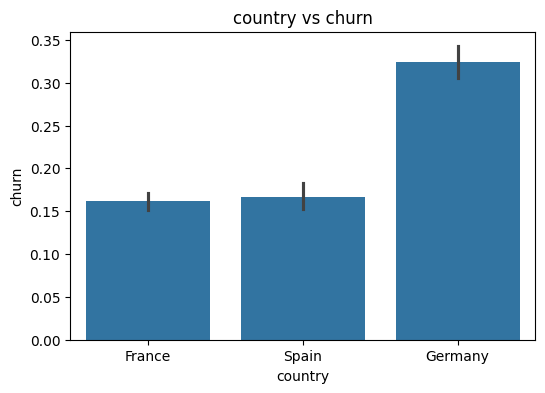


Crosstab:

churn       0    1
country           
France   4204  810
Germany  1695  814
Spain    2064  413

Chi-Square Test
P-value: 3.8303176053541544e-66
Result: Significant relationship exists. Keep this feature.


True

In [21]:
categorical_analysis(data,'country')

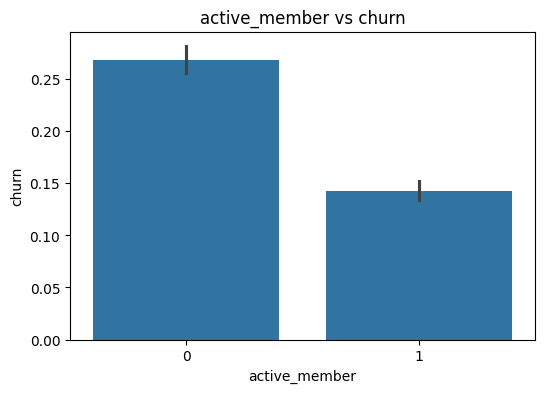


Crosstab:

churn             0     1
active_member            
0              3547  1302
1              4416   735

Chi-Square Test
P-value: 8.785858269303703e-55
Result: Significant relationship exists. Keep this feature.


True

In [22]:
categorical_analysis(data,'active_member')

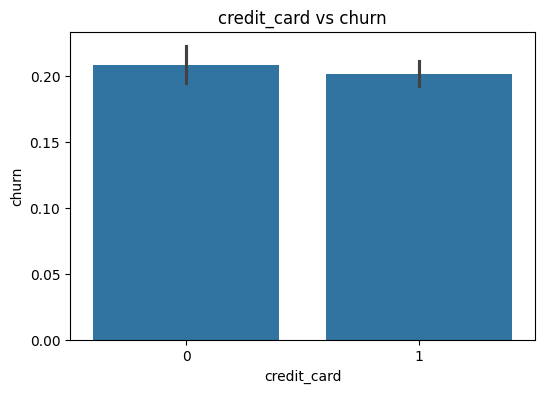


Crosstab:

churn           0     1
credit_card            
0            2332   613
1            5631  1424

Chi-Square Test
P-value: 0.49237236141554686
Result: No significant relationship. Drop this feature.


False

In [23]:
categorical_analysis(data,'credit_card')

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    features, target,
    test_size=0.2,
    stratify=target,
    random_state=42
)

In [25]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

def build_pipeline(num_attributes, cat_attributes):
    num_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    cat_pipeline = Pipeline([
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    full_pipeline = ColumnTransformer([
        ("num", num_pipeline, num_attributes),
        ("cat", cat_pipeline, cat_attributes)
    ])
    return full_pipeline

In [26]:
pipeline = build_pipeline(num_attributes, cat_attributes)
X_train_transformed= pipeline.fit_transform(X_train)

In [27]:
X_test_transformed = pipeline.transform(X_test)

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Logistic Regression
log_reg = LogisticRegression(random_state=42, solver='liblinear') # Added solver to suppress warning
log_reg.fit(X_train_transformed, y_train)

# Decision Tree Classifier
tree_clf = DecisionTreeClassifier(random_state=42)
tree_clf.fit(X_train_transformed, y_train)

# Random Forest Classifier
forest_clf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42
)
forest_clf.fit(X_train_transformed, y_train)

# Make predictions on the transformed test set
log_preds = log_reg.predict(X_test_transformed)
tree_preds = tree_clf.predict(X_test_transformed)
forest_preds = forest_clf.predict(X_test_transformed)

# Calculate Accuracy Scores
log_accuracy = accuracy_score(y_test, log_preds)
tree_accuracy = accuracy_score(y_test, tree_preds)
forest_accuracy = accuracy_score(y_test, forest_preds)

print(f"Logistic Regression Accuracy: {log_accuracy:.4f}")
print(f"Decision Tree Accuracy: {tree_accuracy:.4f}")
print(f"Random Forest Accuracy: {forest_accuracy:.4f}")

Logistic Regression Accuracy: 0.8080
Decision Tree Accuracy: 0.7945
Random Forest Accuracy: 0.8445


In [29]:
from sklearn.metrics import classification_report

print("Logistic Regression")
print(classification_report(y_test, log_preds))

print("Decision Tree")
print(classification_report(y_test, tree_preds))

print("Random Forest")
print(classification_report(y_test, forest_preds))

Logistic Regression
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      1593
           1       0.59      0.19      0.28       407

    accuracy                           0.81      2000
   macro avg       0.71      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000

Decision Tree
              precision    recall  f1-score   support

           0       0.88      0.86      0.87      1593
           1       0.50      0.53      0.51       407

    accuracy                           0.79      2000
   macro avg       0.69      0.70      0.69      2000
weighted avg       0.80      0.79      0.80      2000

Random Forest
              precision    recall  f1-score   support

           0       0.91      0.89      0.90      1593
           1       0.61      0.66      0.63       407

    accuracy                           0.84      2000
   macro avg       0.76      0.78      0.77      2000
weighted avg       0.85   

In [30]:
# Final deployment model

from sklearn.pipeline import Pipeline
import joblib

final_model = Pipeline([
    ("preprocessing", pipeline),
    ("model",forest_clf)
])

final_model.fit(X_train, y_train)

joblib.dump(final_model, "customer_churn_model.pkl")
print("Model saved successfully!")

Model saved successfully!


In [31]:
from google.colab import files

files.download("customer_churn_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [32]:
for col in X_train.columns:
    if X_train[col].dtype != "object":
        print(col, X_train[col].min(), X_train[col].max())

credit_score 350 850
age 18 92
tenure 0 10
balance 0.0 238387.56
products_number 1 4
credit_card 0 1
active_member 0 1
estimated_salary 11.58 199992.48


In [33]:
import sklearn
print(sklearn.__version__)

1.7.2
